# Watermark Benchmark (Class-Based)

It provides:
- A clean benchmark loop (encode -> attack -> decode)
- Attacks with geometric transforms using `order=0`
- BER and timing summaries

## 1. Setup

In [7]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from joblib import Parallel, delayed

from skimage import data
from skimage.io import imread
from skimage.util import img_as_ubyte, img_as_float64, random_noise
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.transform import rotate, rescale, resize, warp, ProjectiveTransform
from skimage.filters import gaussian
from skimage.exposure import adjust_gamma

warnings.filterwarnings("ignore")

ROOT = Path(".")
IMG_DIR = ROOT / "img"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUT_DIR = ROOT / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

from model import WatermarkModel
from utils.sync import synchronise

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.grid": False,
})

print("Setup complete.")

Setup complete.


## 2. Load Images

In [8]:
def load_images(directory: Path, exclude_folder: str = "_old") -> dict[str, np.ndarray]:
    exts = {".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif"}
    out: dict[str, np.ndarray] = {}

    if not directory.exists():
        return out

    for p in sorted(directory.rglob("*")):
        if exclude_folder in p.parts:
            continue
        if p.suffix.lower() not in exts:
            continue
        arr = imread(str(p))
        if arr.ndim == 3 and arr.shape[2] == 4:
            arr = arr[..., :3]
        out[p.stem] = img_as_ubyte(arr)

    return out


def show_gallery(images: dict[str, np.ndarray], max_cols: int = 4) -> None:
    if not images:
        print("No images to display.")
        return
    n = len(images)
    cols = min(max_cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.0 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, (name, img) in zip(axes, images.items()):
        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(name)
        ax.axis("off")
    for ax in axes[len(images):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


images = load_images(IMG_DIR)

if not images:
    print("No images found in img/. Using skimage fallback images.")
    images = {
        "camera": img_as_ubyte(data.camera()),
        "astronaut": img_as_ubyte(data.astronaut()),
    }

print(f"Loaded {len(images)} image(s): {list(images.keys())}")

Loaded 1 image(s): ['tangled']


## 3. Helpers

In [9]:
def make_watermark(n_bits: int, seed: int = SEED) -> np.ndarray:
    return np.random.default_rng(seed).integers(0, 2, n_bits, dtype=np.uint8)


def to_u8(img: np.ndarray) -> np.ndarray:
    return img_as_ubyte(np.clip(img_as_float64(img), 0.0, 1.0))


def extract_lsb_plane(img: np.ndarray) -> np.ndarray:
    img_u8 = to_u8(img)
    channel = img_u8[..., 1] if img_u8.ndim == 3 else img_u8
    return (channel & np.uint8(1)).astype(np.uint8)


def bit_error_rate(original: np.ndarray, decoded: np.ndarray) -> float:
    a = np.asarray(original, dtype=np.uint8).reshape(-1)
    b = np.asarray(decoded, dtype=np.uint8).reshape(-1)
    n = min(len(a), len(b))
    if n == 0:
        return 1.0
    return float(np.mean(a[:n] != b[:n]))


def compute_psnr(reference: np.ndarray, distorted: np.ndarray) -> float:
    try:
        return float(psnr(to_u8(reference), to_u8(distorted), data_range=255))
    except Exception:
        return float("inf")


print("Helpers ready.")

Helpers ready.


## 4. Attacks (geometric transforms use order=0)

In [10]:
def attack_none(img: np.ndarray) -> np.ndarray:
    return to_u8(img)


def attack_rotate(img: np.ndarray, angle: float = 15.0) -> np.ndarray:
    out = rotate(
        img_as_float64(img),
        angle=angle,
        order=0,
        mode="reflect",
        preserve_range=True,
    )
    return to_u8(out)


def attack_scale(img: np.ndarray, factor: float = 0.85) -> np.ndarray:
    img_f = img_as_float64(img)
    ch_axis = 2 if img_f.ndim == 3 else None
    scaled = rescale(
        img_f,
        factor,
        order=0,
        mode="reflect",
        preserve_range=True,
        anti_aliasing=False,
        channel_axis=ch_axis,
    )
    restored = resize(
        scaled,
        img.shape[:2] if img.ndim == 2 else img.shape,
        order=0,
        mode="reflect",
        preserve_range=True,
        anti_aliasing=False,
    )
    return to_u8(restored)


def attack_crop(img: np.ndarray, fraction: float = 0.10) -> np.ndarray:
    h, w = img.shape[:2]
    dy = max(1, int(h * fraction))
    dx = max(1, int(w * fraction))
    cropped = img[dy:h - dy, dx:w - dx]
    if cropped.size == 0:
        return to_u8(img)
    restored = resize(
        img_as_float64(cropped),
        img.shape[:2] if img.ndim == 2 else img.shape,
        order=0,
        mode="reflect",
        preserve_range=True,
        anti_aliasing=False,
    )
    return to_u8(restored)


def attack_shift(img: np.ndarray, shift: int = 10) -> np.ndarray:
    return np.roll(to_u8(img), shift=(shift, shift), axis=(0, 1))


def attack_perspective(img: np.ndarray, strength: float = 0.05) -> np.ndarray:
    h, w = img.shape[:2]
    d = strength * min(h, w)
    src = np.array([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]], dtype=float)
    dst = src + np.array([[-d, -d], [d, -d], [-d, d], [d, d]])
    tform = ProjectiveTransform()
    tform.estimate(src, dst)
    warped = warp(
        img_as_float64(img),
        inverse_map=tform.inverse,
        output_shape=(h, w),
        order=0,
        mode="edge",
        preserve_range=True,
    )
    return to_u8(warped)


def attack_resize_roundtrip(img: np.ndarray, factor: float = 0.5) -> np.ndarray:
    h, w = img.shape[:2]
    small_shape = (max(1, int(h * factor)), max(1, int(w * factor)))
    if img.ndim == 3:
        small_shape = (small_shape[0], small_shape[1], img.shape[2])
    small = resize(
        img_as_float64(img),
        small_shape,
        order=0,
        mode="reflect",
        preserve_range=True,
        anti_aliasing=False,
    )
    restored = resize(
        small,
        img.shape[:2] if img.ndim == 2 else img.shape,
        order=0,
        mode="reflect",
        preserve_range=True,
        anti_aliasing=False,
    )
    return to_u8(restored)


def attack_noise(img: np.ndarray, var: float = 0.005) -> np.ndarray:
    noisy = random_noise(img_as_float64(img), mode="gaussian", var=var, rng=SEED)
    return to_u8(noisy)


def attack_blur(img: np.ndarray, sigma: float = 2.0) -> np.ndarray:
    out = gaussian(
        img_as_float64(img),
        sigma=sigma,
        channel_axis=2 if img.ndim == 3 else None,
        preserve_range=True,
    )
    return to_u8(out)


def attack_gamma(img: np.ndarray, gamma: float = 1.8) -> np.ndarray:
    return to_u8(adjust_gamma(img_as_float64(img), gamma=gamma))


def attack_brightness(img: np.ndarray, offset: float = 0.15) -> np.ndarray:
    return to_u8(np.clip(img_as_float64(img) + offset, 0.0, 1.0))


def attack_jpeg(img: np.ndarray, quality: int = 50) -> np.ndarray:
    import io
    try:
        from PIL import Image as PILImage
        buf = io.BytesIO()
        PILImage.fromarray(to_u8(img)).save(buf, format="JPEG", quality=quality)
        buf.seek(0)
        return to_u8(np.array(PILImage.open(buf)))
    except Exception:
        fallback = gaussian(img_as_float64(img), sigma=1 + (100 - quality) / 50)
        return to_u8(fallback)


ATTACKS: dict[str, callable] = {
    "none": attack_none,
    "rotate_15": lambda x: attack_rotate(x, angle=15.0),
    "scale_0.85": lambda x: attack_scale(x, factor=0.85),
    "crop_10pct": lambda x: attack_crop(x, fraction=0.10),
    "shift_10": lambda x: attack_shift(x, shift=10),
    # "perspective_5pct": lambda x: attack_perspective(x, strength=0.05),
    "resize_x0.5": lambda x: attack_resize_roundtrip(x, factor=0.5),
    "noise_var0.005": lambda x: attack_noise(x, var=0.005),
    "blur_s2": lambda x: attack_blur(x, sigma=2.0),
    "gamma_1.8": lambda x: attack_gamma(x, gamma=1.8),
    "brightness_plus": lambda x: attack_brightness(x, offset=0.15),
    "jpeg_q50": lambda x: attack_jpeg(x, quality=50),
}

print(f"{len(ATTACKS)} attacks registered.")

11 attacks registered.


Model initialized.
Image loaded.
Watermark generated.
Image watermarked.


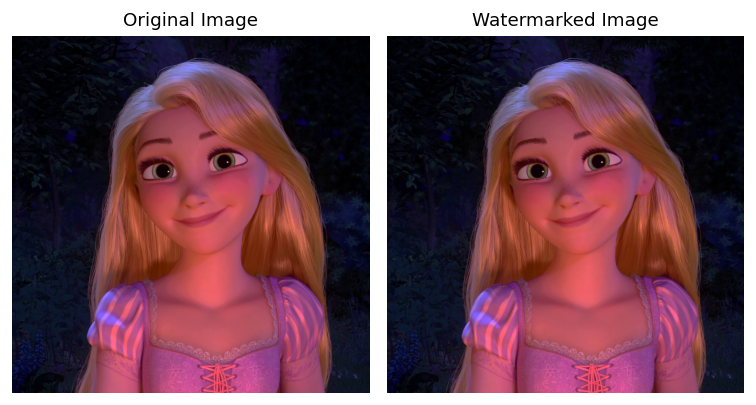

Range channel: 0 to 234
Range denoised: -2.1803253690129172e-16 to 0.9151784933982865
Denoised dtype: float64


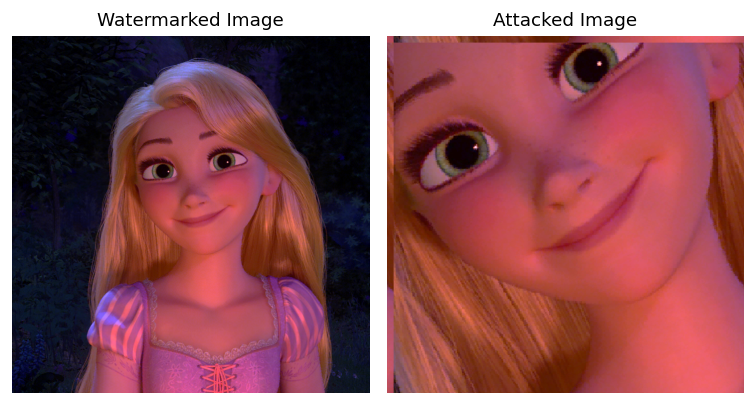

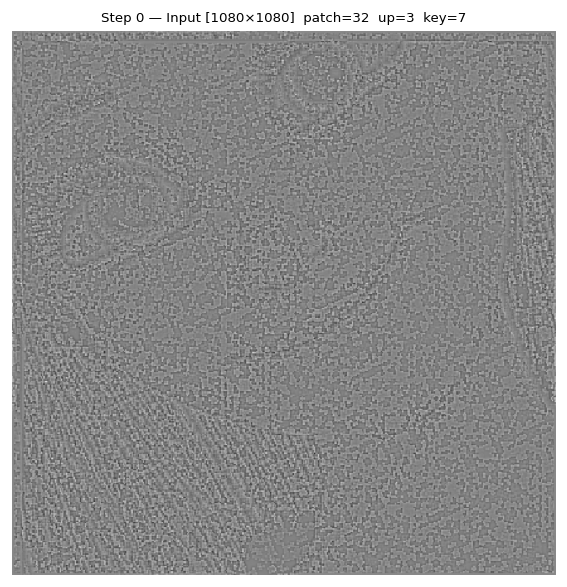

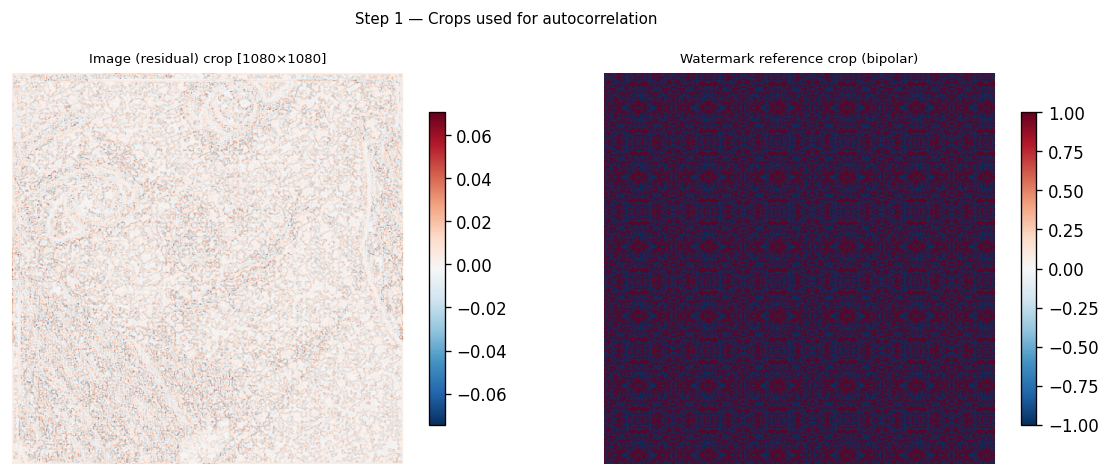

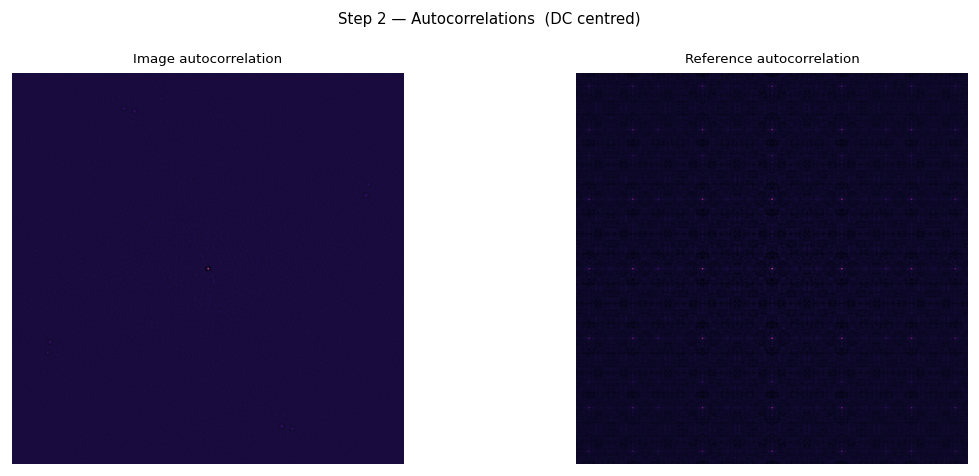

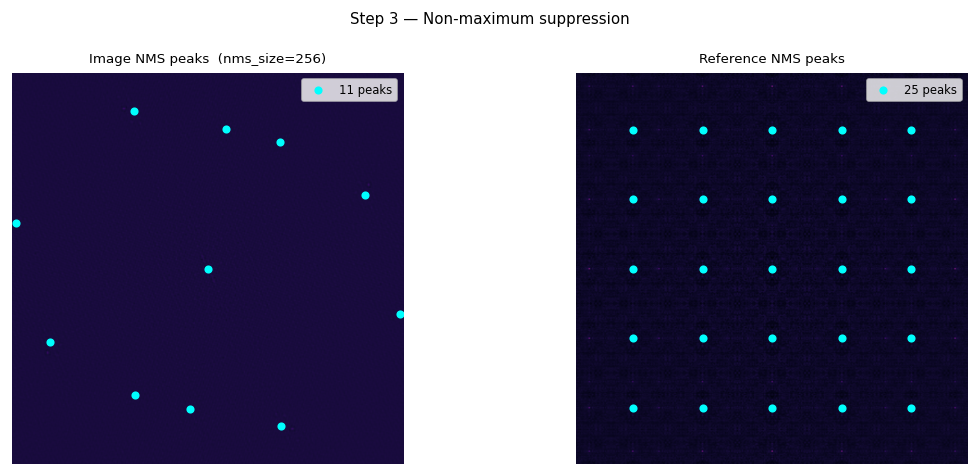

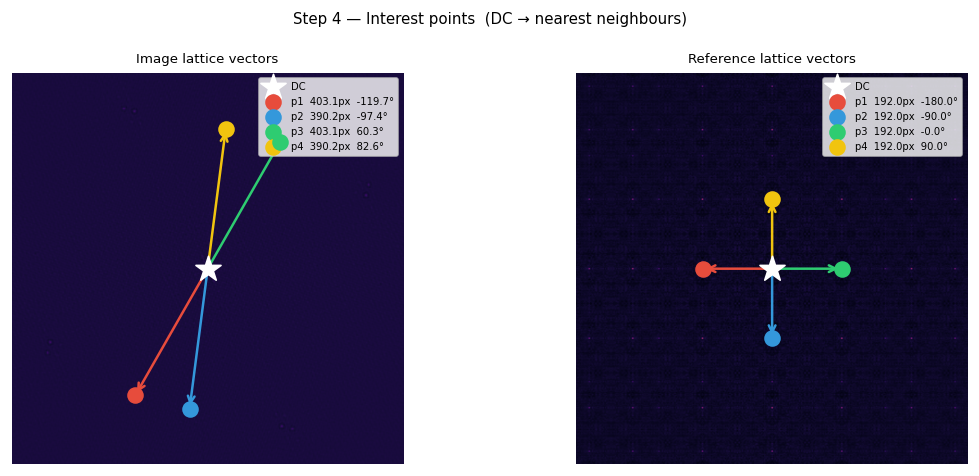

[step 5] Detected attack : rotation=-60.26°  scale=2.0995
[step 5] Correction applied: rotation=+42.13°  scale=1.6725


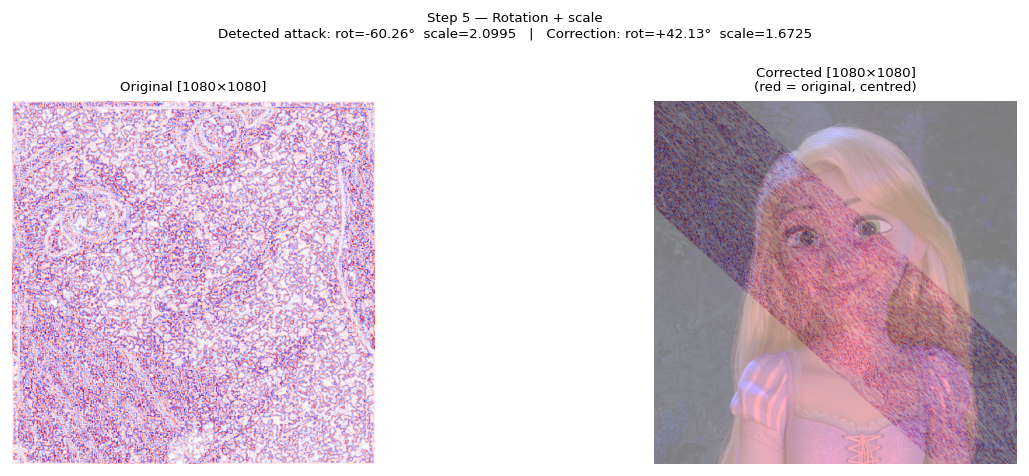

[step 6] translation dy=-28.0px  dx=-31.0px  flip='normal'


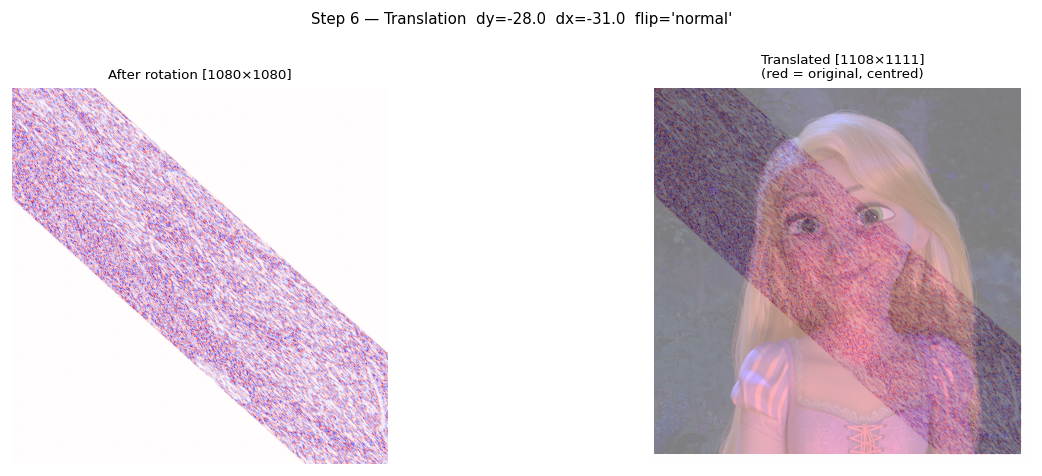

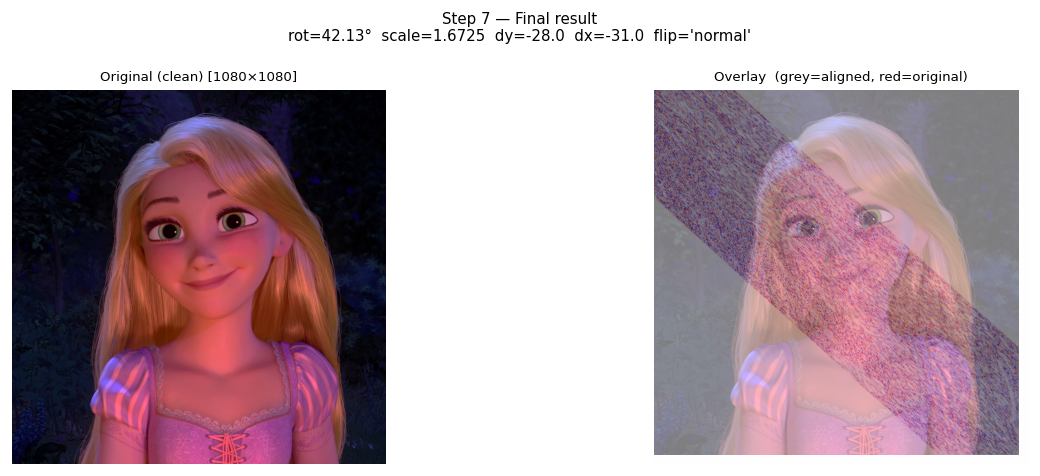

(array([[-0.0124404 ,  0.01412109,  0.0102249 , ...,  0.        ,
          0.        ,  0.        ],
        [-0.00281595, -0.01566793,  0.01493245, ...,  0.        ,
          0.        ,  0.        ],
        [-0.00141861, -0.0057048 , -0.01510381, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ]], shape=(1108, 1111)),
 'normal')

In [13]:
import skimage as sk
from scipy.signal import wiener
from utils.patch import *

from utils.sync import *

def expand_peaks(image , expansion_size=3):
    expanded = np.zeros_like(image)
    peaks = np.argwhere(image > 0)
    for peak in peaks:
        x, y = peak
        expanded[ max (0, x-expansion_size): min (image.shape[0], x+expansion_size+1), max (0, y-expansion_size): min (image.shape[1], y+expansion_size+1)] = 1
    return expanded


model = WatermarkModel(message_length=100, nms_size_ac=int(2*4*32), upsample_factor=3, patch_size=32)
print("Model initialized.")

# image = images["ICIP_GC1_JPT_WM_R062"]
image = images["tangled"]
print("Image loaded.")

watermark = make_watermark(model.message_length)
print("Watermark generated.")

watermarked = model.encode(image, watermark)
print("Image watermarked.")

sk.io.imsave(OUTPUT_DIR / "watermarked.png", watermarked)
sk.io.imsave(OUTPUT_DIR / "watermark.png", image - watermarked)

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(watermarked)
plt.title("Watermarked Image")
plt.axis("off")
plt.tight_layout()
plt.show()

img_f = sk.img_as_float(watermarked).astype(np.float32)

img_f = attack_rotate(img_f, angle=25.0)  # Example attack: rotate by 25 degrees
img_f = attack_scale(img_f, factor=0.8)  # Example attack: scale by 70%
img_f = attack_crop(img_f, fraction=0.30)  # Example attack: crop 30% from borders
img_f = attack_shift(img_f, shift=20)
H, W  = img_f.shape[:2]

channel = model._get_channel(img_f)   # (H, W)

# 3. Wiener denoising — noise power ≈ mean energy of the watermark signal
print("Range channel:", channel.min(), "to", channel.max())
channel = sk.img_as_float(channel)
ref = build_reference_patch_bipolar((H, W), model.patch_size, model.key, model.tile_mode, model.upsample_factor).astype(float)
nvf = model._compute_nvf(channel)
strength = model._embedding_strength(nvf)
ref_weighted = ref * strength


denoised    = wiener(channel, mysize=9, noise=np.var(ref_weighted))

print("Range denoised:", denoised.min(), "to", denoised.max())
print("Denoised dtype:", denoised.dtype)
# 4. Residual ≈ watermark signal (float32, shape (H, W))
residual = (channel - denoised)

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(watermarked)
plt.title("Watermarked Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(img_f, cmap="gray")
plt.title("Attacked Image")
plt.axis("off")
plt.tight_layout()
plt.show()
synchronise_debug(residual, original=image, patch_size=model.patch_size, key=model.key, tile_mode=model.tile_mode, nms_size_ac=model.nms_size_ac, upsample_factor=model.upsample_factor)



In [12]:
watermark_extracted = model.decode(img_f)

print("BER:", bit_error_rate(watermark, watermark_extracted))


BER: 0.0


## 5. Model + Benchmark

In [14]:
MESSAGE_LENGTH = 100
watermark = make_watermark(MESSAGE_LENGTH, seed=SEED)

model = WatermarkModel(alpha_1=4, alpha_2=5, message_length=MESSAGE_LENGTH, use_ecc=True, ecc_repetitions=5, msg_repetitions=1, upsample_factor=4, patch_size=32)

def run_benchmark(
    model: WatermarkModel,
    images: dict[str, np.ndarray],
    attacks: dict[str, callable],
    watermark: np.ndarray,
    verbose: bool = True,
    n_jobs: int = -1,
    backend: str = "loky",
) -> pd.DataFrame:
    def compute_weighted_mse(original: np.ndarray, stego: np.ndarray) -> float:
        original = original.astype(np.float32)
        stego = stego.astype(np.float32)

        return np.mean(model._compute_nvf(original) * (original - stego) ** 2)


    def compute_wpsnr(original: np.ndarray, stego: np.ndarray) -> float:
        wmse = compute_weighted_mse(original, stego)

        if wmse == 0:
            return float("inf")

        return 10 * np.log10((255 ** 2) / wmse)
    
    def run_one_image(image_name: str, image: np.ndarray) -> list[dict]:
        src = to_u8(image)

        t0 = time.perf_counter()
        wm_img = model.encode(src, watermark)
        encode_time = time.perf_counter() - t0
        psnr_embed = compute_psnr(src, wm_img)
        wpsnr_embed = compute_wpsnr(src, wm_img)

        image_records: list[dict] = []
        for attack_name, attack_fn in attacks.items():
            attacked = to_u8(attack_fn(wm_img))

            t1 = time.perf_counter()
            decoded = model.decode(attacked)
            decode_time = time.perf_counter() - t1

            decoded_bits = np.asarray(decoded, dtype=np.uint8).reshape(-1)
            n = min(len(watermark), len(decoded_bits))
            ber_val = bit_error_rate(watermark[:n], decoded_bits[:n])

            image_records.append({
                "image": image_name,
                "attack": attack_name,
                "ber": ber_val,
                "encode_time_s": encode_time,
                "decode_time_s": decode_time,
                "psnr_embed": psnr_embed,
                "wpsnr_embed": wpsnr_embed,
            })
        return image_records

    # if n_jobs == -1:
    #     worker_count = min(4, len(images))
    # else:
    #     worker_count = max(1, n_jobs)
    worker_count = n_jobs

    if verbose:
        total = len(images) * len(attacks)
        print(f"Running {total} tests in parallel with n_jobs={worker_count} ({backend}).")

    if worker_count == 1:
        nested_records = [run_one_image(name, image) for name, image in images.items()]
    else:
        nested_records = Parallel(n_jobs=worker_count, backend=backend, verbose=10)(
            delayed(run_one_image)(name, image) for name, image in images.items()
        )

    records = [record for image_records in nested_records for record in image_records]
    return pd.DataFrame(records)


results = run_benchmark(model, images, ATTACKS, watermark, verbose=True, n_jobs=-1, backend="loky")
print(f"Collected {len(results)} records.")
display(results.head(10))

Running 11 tests in parallel with n_jobs=-1 (loky).


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


/home/fitzwilliam/Documents/multimedia_security_and_privacy/solution1/.venv/lib/python3.12/site-packages/scipy/signal/_signaltools.py:1728: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
/home/fitzwilliam/Documents/multimedia_security_and_privacy/solution1/.venv/lib/python3.12/site-packages/scipy/signal/_signaltools.py:1728: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)


Collected 11 records.


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   18.0s


,image,attack,ber,encode_time_s,decode_time_s,psnr_embed,wpsnr_embed
0,tangled,none,0.0,0.154759,1.032727,40.704964,41.431461
1,tangled,rotate_15,0.0,0.154759,1.036751,40.704964,41.431461
2,tangled,scale_0.85,0.0,0.154759,1.009533,40.704964,41.431461
3,tangled,crop_10pct,0.0,0.154759,1.121837,40.704964,41.431461
4,tangled,shift_10,0.0,0.154759,1.060917,40.704964,41.431461
5,tangled,resize_x0.5,0.0,0.154759,1.096149,40.704964,41.431461
6,tangled,noise_var0.005,0.0,0.154759,0.921914,40.704964,41.431461
7,tangled,blur_s2,0.0,0.154759,0.842858,40.704964,41.431461
8,tangled,gamma_1.8,0.0,0.154759,0.828578,40.704964,41.431461
9,tangled,brightness_plus,0.0,0.154759,0.834375,40.704964,41.431461


## 6. Summary Visualizations

Mean BER by attack (lower is better):


,mean_ber,std_ber,mean_decode_ms,mean_psnr,mean_wpsnr
attack,,,,,
blur_s2,0.00,NaN,842.858468,40.704964,41.431461
brightness_plus,0.00,NaN,834.374792,40.704964,41.431461
crop_10pct,0.00,NaN,1121.836539,40.704964,41.431461
gamma_1.8,0.00,NaN,828.578336,40.704964,41.431461
noise_var0.005,0.00,NaN,921.914375,40.704964,41.431461
none,0.00,NaN,1032.727358,40.704964,41.431461
resize_x0.5,0.00,NaN,1096.149104,40.704964,41.431461
rotate_15,0.00,NaN,1036.751215,40.704964,41.431461
shift_10,0.00,NaN,1060.917180,40.704964,41.431461


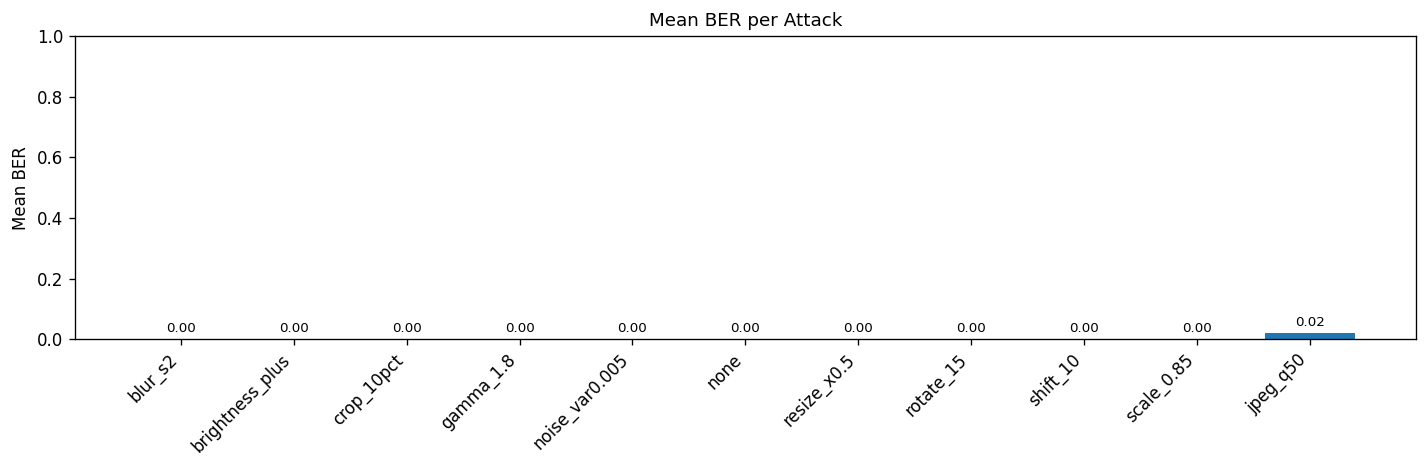

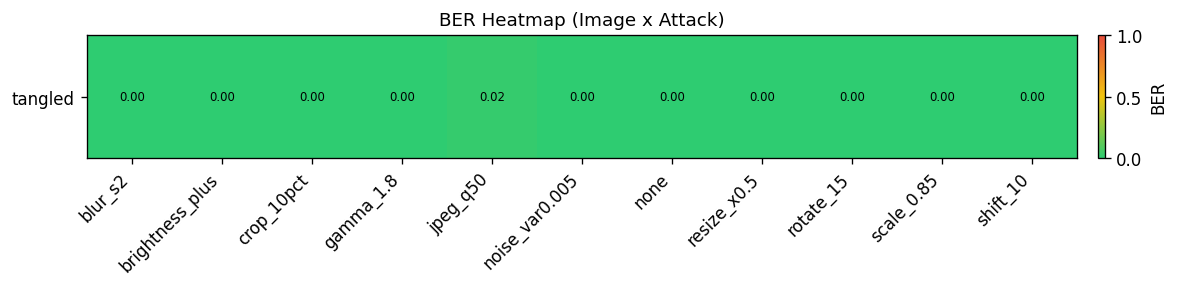

In [15]:
attack_summary = (
    results.groupby("attack")
    .agg(
        mean_ber=("ber", "mean"),
        std_ber=("ber", "std"),
        mean_decode_ms=("decode_time_s", lambda x: x.mean() * 1000),
        mean_psnr=("psnr_embed", "mean"),
        mean_wpsnr=("wpsnr_embed", "mean"),
    )
    .sort_values("mean_ber")
)

print("Mean BER by attack (lower is better):")
display(attack_summary)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(attack_summary.index, attack_summary["mean_ber"].values, color="#1f77b4")
ax.set_ylim(0, 1)
ax.set_ylabel("Mean BER")
ax.set_title("Mean BER per Attack")
ax.set_xticks(np.arange(len(attack_summary.index)))
ax.set_xticklabels(attack_summary.index, rotation=45, ha="right")
for b, v in zip(bars, attack_summary["mean_ber"].values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

pivot = results.pivot_table(index="image", columns="attack", values="ber", aggfunc="mean")

cmap = mcolors.LinearSegmentedColormap.from_list("ber_map", ["#2ecc71", "#f1c40f", "#e74c3c"])
fig, ax = plt.subplots(figsize=(max(10, 0.8 * pivot.shape[1]), max(2.5, 0.7 * pivot.shape[0] + 1.5)))
im = ax.imshow(pivot.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(np.arange(pivot.shape[1]))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(pivot.shape[0]))
ax.set_yticklabels(pivot.index)
ax.set_title("BER Heatmap (Image x Attack)")

for r in range(pivot.shape[0]):
    for c in range(pivot.shape[1]):
        value = float(pivot.values[r, c])
        ax.text(c, r, f"{value:.2f}", ha="center", va="center", color="white" if value > 0.55 else "black", fontsize=7)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="BER")
plt.tight_layout()
plt.show()

In [16]:
from itertools import product

TARGET_PSNR_VALUES = [30, 35, 40, 45]
CALIBRATION_IMAGE_COUNT = min(4, len(images))
CALIBRATION_ATTACK_NAMES = ["none", "rotate_15", "perspective_5pct", "jpeg_q50"]

ALPHA_1_GRID = [0.25, 0.5, 1.0, 2.0]
ALPHA_2_GRID = [5.0, 10.0, 20.0, 30.0]

calibration_images = dict(list(images.items())[:CALIBRATION_IMAGE_COUNT])
calibration_attacks = {name: ATTACKS[name] for name in CALIBRATION_ATTACK_NAMES if name in ATTACKS}

def build_model(alpha_1: float, alpha_2: float) -> WatermarkModel:
    return WatermarkModel(
        alpha_1=alpha_1,
        alpha_2=alpha_2,
        message_length=MESSAGE_LENGTH,
        use_ecc=True,
        ecc_repetitions=5,
        msg_repetitions=1,
        upsample_factor=4,
        patch_size=32,
    )


def evaluate_alpha_pair(alpha_1: float, alpha_2: float) -> dict:
    candidate_model = build_model(alpha_1, alpha_2)
    candidate_results = run_benchmark(
        candidate_model,
        calibration_images,
        calibration_attacks,
        watermark,
        verbose=False,
        n_jobs=1,
    )

    return {
        "alpha_1": alpha_1,
        "alpha_2": alpha_2,
        "mean_psnr": float(candidate_results["psnr_embed"].mean()),
        "mean_ber": float(candidate_results["ber"].mean()),
        "mean_decode_ms": float(candidate_results["decode_time_s"].mean() * 1000),
        "mean_wpsnr": float(candidate_results["wpsnr_embed"].mean()),
    }


candidate_grid = list(product(ALPHA_1_GRID, ALPHA_2_GRID))
candidate_rows = Parallel(n_jobs=min(4, len(candidate_grid)), backend="loky")(
    delayed(evaluate_alpha_pair)(alpha_1, alpha_2)
    for alpha_1, alpha_2 in candidate_grid
)
candidate_table = pd.DataFrame(candidate_rows)

print("Calibration search results:")
display(candidate_table.sort_values(["mean_ber", "mean_psnr"]).reset_index(drop=True))

best_rows: list[dict] = []
for target_psnr in TARGET_PSNR_VALUES:
    ranked = (
        candidate_table.assign(psnr_error=(candidate_table["mean_psnr"] - target_psnr).abs())
        .sort_values(["psnr_error", "mean_ber", "mean_decode_ms"], ascending=[True, True, True])
        .reset_index(drop=True)
    )
    best = ranked.iloc[0].to_dict()
    best["target_psnr"] = target_psnr
    best_rows.append(best)

best_alpha_table = pd.DataFrame(best_rows)[
    ["target_psnr", "alpha_1", "alpha_2", "mean_psnr", "psnr_error", "mean_ber", "mean_decode_ms", "mean_wpsnr"]
].sort_values("target_psnr")

print("Best alpha pair for each target PSNR:")
display(best_alpha_table)

best_models = {
    int(row.target_psnr): build_model(float(row.alpha_1), float(row.alpha_2))
    for row in best_alpha_table.itertuples(index=False)
}

print("Best model objects prepared for targets:", sorted(best_models))

/home/fitzwilliam/Documents/multimedia_security_and_privacy/solution1/.venv/lib/python3.12/site-packages/scipy/signal/_signaltools.py:1728: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
/home/fitzwilliam/Documents/multimedia_security_and_privacy/solution1/.venv/lib/python3.12/site-packages/scipy/signal/_signaltools.py:1728: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)
/home/fitzwilliam/Documents/multimedia_security_and_privacy/solution1/.venv/lib/python3.12/site-packages/scipy/signal/_signaltools.py:1728: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
/home/fitzwilliam/Documents/multimedia_security_and_privacy/solution1/.venv/lib/python3.12/site-packages/scipy/signal/_signaltools.py:1728: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)
/home/fitzwilliam/Documents/multimedia_security_and_privacy/solution1/.venv/lib/python3.12/site-packages/scipy/sig

Error during bit extraction: Need at least 5 peaks, found 1.
Error during bit extraction: Need at least 5 peaks, found 1.
Calibration search results:


,alpha_1,alpha_2,mean_psnr,mean_ber,mean_decode_ms,mean_wpsnr
0,1.00,30.0,34.879887,0.003333,1106.733847,37.380783
1,2.00,30.0,34.352886,0.006667,947.296739,36.641331
2,0.50,30.0,35.131605,0.006667,1454.927578,37.739178
3,0.25,30.0,35.251518,0.006667,2142.184078,37.910400
4,2.00,20.0,37.287385,0.013333,955.016362,39.380238
5,1.00,20.0,38.097706,0.016667,1150.964272,40.493317
6,2.00,10.0,41.704610,0.023333,1060.176642,43.351257
7,1.00,10.0,43.311690,0.026667,1116.543496,45.433426
8,1.00,5.0,47.794767,0.060000,1174.242989,49.493225
9,0.50,5.0,48.810642,0.063333,1432.229008,50.669510


Best alpha pair for each target PSNR:


,target_psnr,alpha_1,alpha_2,mean_psnr,psnr_error,mean_ber,mean_decode_ms,mean_wpsnr
0,30,2.00,30.0,34.352886,4.352886,0.006667,947.296739,36.641331
1,35,1.00,30.0,34.879887,0.120113,0.003333,1106.733847,37.380783
2,40,0.25,20.0,38.667199,1.332801,0.173333,2002.387280,41.299057
3,45,2.00,5.0,44.933314,0.066686,0.156667,1042.380724,46.077835


Best model objects prepared for targets: [30, 35, 40, 45]
